# Real Singlet extension of the Standard Model

In [2]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec

from cosmoTransitions import pathDeformation, transitionFinder
from cosmoTransitions import pathDeformation

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar

from xSM_Model import xSM

## Limiting Test: SM

In [7]:
model = xSM()
v = model.v_os
res = minimize_scalar(
    lambda phi: model.Vtot(np.array([[phi, u]]), 0.0).item(),
    bounds=(50, 350),
    method='bounded'
)
v_num = res.x
print(f"Numerical vev (Vtot, T=0): {v_num:.3f} GeV")
print(f"CW shift: {abs(v_num - model.v_os) / model.v_os * 100:.3f}%")

Numerical vev (Vtot, T=0): 246.220 GeV
CW shift: 0.000%


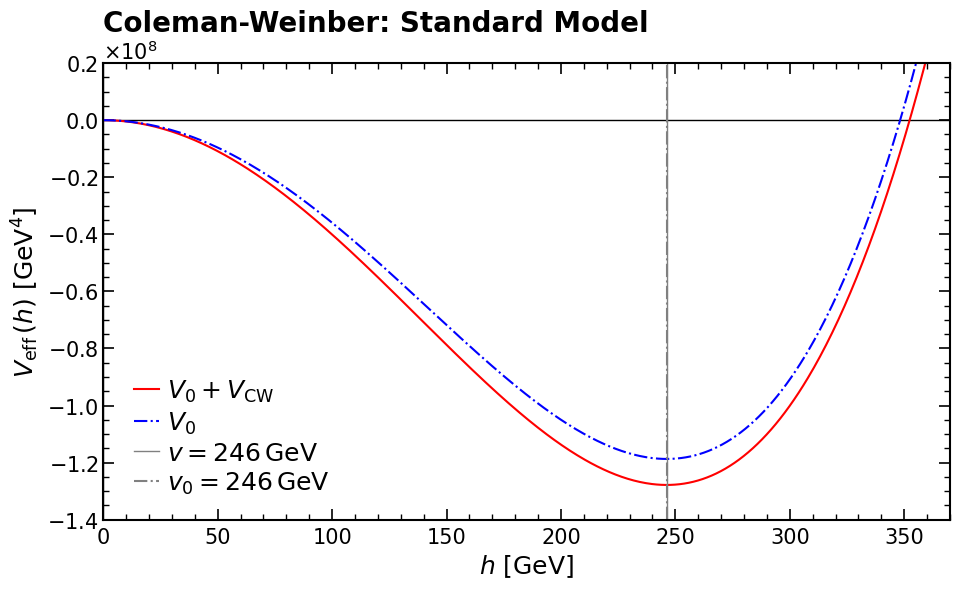

In [16]:
h_vals = np.linspace(-500, 500, 1500)
X = np.column_stack([h_vals, np.zeros_like(h_vals)])

V_tree   = model.V0(X)
V_tot_0  = model.Vtot(X, 0.0)

fig, ax = plt.subplots(figsize=(9.7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(h_vals, V_tot_0-model.Vtot(np.array([[0.0, 0.0]]), 0.0), label=r'$V_0 + V_\mathrm{CW}$', color='r', lw=1.5, ls='-')
ax.plot(h_vals, V_tree-model.V0(np.array([[0.0, 0.0]])), label=r'$V_0$', color='b', lw=1.5, ls='-.')

ax.axvline(v_num, label=rf'$v={float(np.squeeze(v_num)):.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-', alpha=1)
ax.axvline(v, label=rf'$v_0={v:.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.5, ls='-.', alpha=1)

ax.set_xlim(0, 370)
ax.set_ylim(-1.4e8, 2e7)

ax.set_xlabel(r'$h$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(h)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=5)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.003),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Coleman-Weinber: Standard Model", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\SM_CW.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Define the Model

In [75]:
def physical_to_lagrangian(m1, m2, theta, v, u, lHS, lS):
    """
    Convert physical parameters to xSM Lagrangian parameters.

    Inputs
    ------
    m1, m2  : scalar mass eigenvalues (GeV), m1 < m2 convention
    theta   : mixing angle (rad)
    v, u    : Higgs and singlet vevs (GeV)
    lHS     : quartic portal lambda_HS
    lS      : singlet quartic lambda_S

    Outputs
    -------
    dict with keys: lH, muHS, mu3, muH2, muS2
    (lHS and lS are inputs, returned unchanged for completeness)
    """
    ct = np.cos(theta)
    st = np.sin(theta)

    # Mass matrix elements from eigenvalues + rotation
    Mhh = m1**2 * ct**2 + m2**2 * st**2
    Mss = m1**2 * st**2 + m2**2 * ct**2
    Mhs = (m1**2 - m2**2) * ct * st

    # Quartic couplings from diagonal mass matrix elements
    lH   = Mhh / (2.0 * v**2)

    # Off-diagonal: Mhs = lHS*v*u + muHS*v  =>  muHS = Mhs/v - lHS*u
    muHS = Mhs / v  -  lHS * u

    # Singlet diagonal: Mss = 2*lS*u^2 - mu3*u - muHS*v^2/(2u)
    # => mu3 = (2*lS*u^2 - Mss - muHS*v^2/(2u)) / u
    if abs(u) > 1e-6:
        mu3 = (2.0*lS*u**2  -  Mss  -  muHS*v**2/(2.0*u)) / u
    else:
        mu3 = 0.0   # u=0: mu3 is unconstrained, set to zero

    # Mass parameters from tadpole conditions
    muH2 = lH*v**2  +  0.5*lHS*u**2  +  muHS*u
    if abs(u) > 1e-6:
        muS2 = 0.5*lHS*v**2  +  muHS*v**2/(2.0*u)  +  lS*u**2  -  mu3*u
    else:
        muS2 = 0.0

    return dict(lH=lH, lHS=lHS, muHS=muHS, lS=lS, mu3=mu3, muH2=muH2, muS2=muS2)

params = physical_to_lagrangian(
    m1    = 125.20,   # GeV  -- SM-like Higgs, fixed
    m2    = 200.0,    # GeV  -- singlet-like scalar, not too heavy
    theta = 0.2,      # rad  -- moderate mixing, enhances cubic
    v     = 246.22,   # GeV
    u     = 30.0,     # GeV  -- nonzero singlet vev drives Z2-breaking cubics
    lHS   = 0.25,     #      -- portal, moderate
    lS    = 1.0,      #      -- large singlet self-coupling strengthens barrier
)
print(params)

{'lH': 0.13719859251708588, 'lHS': 0.25, 'muHS': -26.736019819519598, 'lS': 1.0, 'mu3': -340.85676605207834, 'muH2': 7627.986446244307, 'muS2': -8310.463905215514}


In [77]:
model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3']},
            v=246.22, u=40.0)
v = model.v_os
u = model.u_os

res = minimize_scalar(
    lambda phi: model.Vtot(np.array([[phi, u]]), 0.0).item(),
    bounds=(50, 350),
    method='bounded'
)
v_num = res.x
print(f"Numerical vev (Vtot, T=0): {v_num:.3f} GeV")
print(f"CW shift: {abs(v_num - model.v_os) / model.v_os * 100:.3f}%")

Numerical vev (Vtot, T=0): 246.220 GeV
CW shift: 0.000%


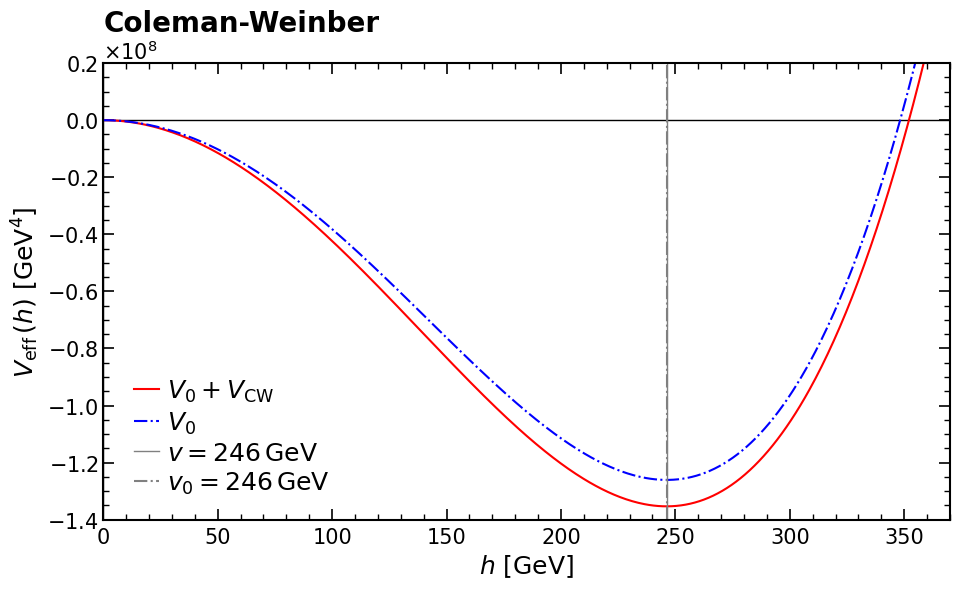

In [81]:
h_vals = np.linspace(-500, 500, 1500)
X = np.column_stack([h_vals, np.zeros_like(h_vals)+u])

V_tree   = model.V0(X)
V_tot_0  = model.Vtot(X, 0.0)

fig, ax = plt.subplots(figsize=(9.7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(h_vals, V_tot_0-model.Vtot(np.array([[0.0, u]]), 0.0), label=r'$V_0 + V_\mathrm{CW}$', color='r', lw=1.5, ls='-')
ax.plot(h_vals, V_tree-model.V0(np.array([[0.0, u]])), label=r'$V_0$', color='b', lw=1.5, ls='-.')

ax.axvline(v_num, label=rf'$v={float(np.squeeze(v_num)):.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-', alpha=1)
ax.axvline(v, label=rf'$v_0={v:.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.5, ls='-.', alpha=1)

ax.set_xlim(0, 370)
ax.set_ylim(-1.4e8, 2e7)

ax.set_xlabel(r'$h$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(h)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=5)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.003),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Coleman-Weinber", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\CW.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [83]:
model.findAllTransitions()
print("Done!")

Tracing phase starting at x = [246.21999934  39.99999995] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
..............................................................................................................................................................................................
Tracing phase starting at x = [-6.89216275e-05 -5.14328615e+01] ; t = 138.30054516330932
Tracing minimum down
traceMinimum t0 = 138.301
............................
Tracing minimum up
traceMinimum t0 = 138.301
..............................................................................
Tracing phase starting at x = [ 79.46741736 -39.79599939] ; t = 136.69364780955587
Tracing minimum down
traceMinimum t0 = 136.694
......................................................
Tracing minimum up
traceMinimum t0 = 136.694
......................................................................................
Tunneling from phase 0 to phase 2 at T=137.2992
high_vev = [139.89390235   7.7263781 ]
low_vev =

In [85]:
for i, trans in enumerate(model.TnTrans):
    Tc   = trans['Tnuc']
    high = trans['high_vev']
    low  = trans['low_vev']
    xi_c = abs(low[0] - high[0]) / Tc
    print(f"Transition {i}:  Tc = {Tc:.2f} GeV  |  xi_c = {xi_c:.4f}")

Transition 0:  Tc = 137.50 GeV  |  xi_c = 0.0000
Transition 1:  Tc = 133.54 GeV  |  xi_c = 0.2859


In [87]:
trans = model.TnTrans[1]
Tc    = trans['Tnuc']
high  = trans['high_vev']
low   = trans['low_vev']

# Polish the minima numerically
def Vtot_scalar(X, T):
    return model.Vtot(np.array([X]), T)[0]

res_high = minimize(Vtot_scalar, high, args=(Tc,), method='Nelder-Mead',
                    options={'xatol':1e-6, 'fatol':1e-6})
res_low  = minimize(Vtot_scalar, low,  args=(Tc,), method='Nelder-Mead',
                    options={'xatol':1e-6, 'fatol':1e-6})

high_min = res_high.x
low_min  = res_low.x
xi_c     = abs(low_min[0] - high_min[0]) / Tc

print(f"Tc     = {Tc:.2f} GeV")
print(f"high phase: (φ_h, φ_s) = ({high_min[0]:.2f}, {high_min[1]:.2f}) GeV")
print(f"low  phase: (φ_h, φ_s) = ({low_min[0]:.2f}, {low_min[1]:.2f}) GeV")
print(f"ξ_c    = {xi_c:.4f}")

Tc     = 133.54 GeV
high phase: (φ_h, φ_s) = (157.66, 18.14) GeV
low  phase: (φ_h, φ_s) = (119.48, -23.22) GeV
ξ_c    = 0.2859


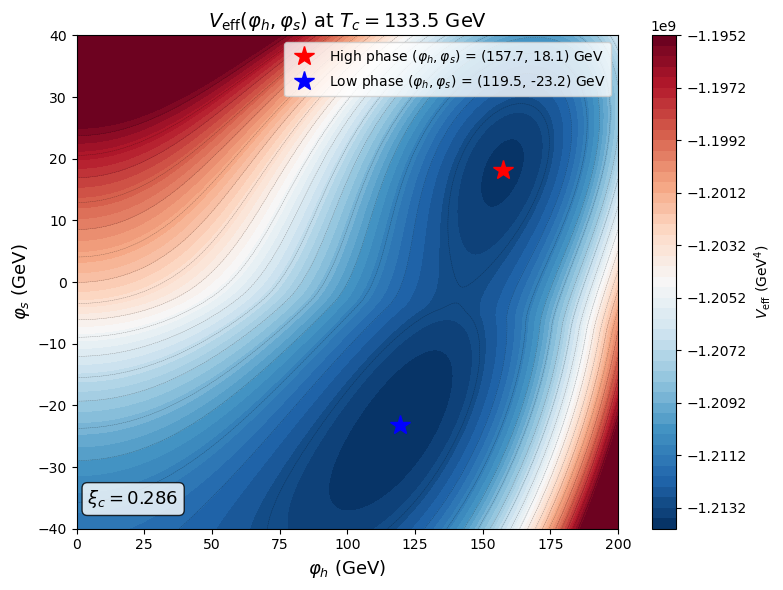

In [99]:
fig, ax = plt.subplots(figsize=(8, 6))

# Grid in (h, s)
h_vals = np.linspace(0, 200, 300)
s_vals = np.linspace(-40, 40, 300)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, Tc).reshape(H.shape)

# Clip for contrast
V_plot = np.clip(V_grid, np.percentile(V_grid, 2), np.percentile(V_grid, 95))

cp = ax.contourf(H, S, V_plot, levels=60, cmap='RdBu_r')
ax.contour(H, S, V_plot, levels=20, colors='k', linewidths=0.3, alpha=0.4)
plt.colorbar(cp, ax=ax, label=r'$V_{\rm eff}$ (GeV$^4$)')

# Mark polished minima
ax.plot(high_min[0], high_min[1], 'r*', markersize=15, zorder=5,
        label=rf'High phase $(\varphi_h, \varphi_s)$ = ({high_min[0]:.1f}, {high_min[1]:.1f}) GeV')
ax.plot(low_min[0],  low_min[1],  'b*', markersize=15, zorder=5,
        label=rf'Low phase $(\varphi_h, \varphi_s)$ = ({low_min[0]:.1f}, {low_min[1]:.1f}) GeV')

ax.set_xlabel(r'$\varphi_h$ (GeV)', fontsize=13)
ax.set_ylabel(r'$\varphi_s$ (GeV)', fontsize=13)
ax.set_title(rf'$V_{{\rm eff}}(\varphi_h, \varphi_s)$ at $T_c = {Tc:.1f}$ GeV', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.text(0.02, 0.05, rf'$\xi_c = {xi_c:.3f}$', transform=ax.transAxes,
        fontsize=13, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("Figures\Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()